# Model Performance Analysis

*Evaluating Our EM Model Performance (and boosted performance) Along Ground Truth Data*

In [51]:
# Import in packages
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Read in boosted predictions and ground truth data
preds = pd.read_parquet("../boosted_preds.parquet")
ground_truth = pd.read_csv("../ground_truth.csv")

In [7]:
# Create id features to align with mentions data
ground_truth['id_1870'] = "ALB-CN-1870-" + ground_truth['1870_line'].astype(str)
ground_truth['id_1880'] = "ALB-CN-1880-" + ground_truth['1880_line'].astype(str)

In [18]:
# Join matches on to ground truth data
data = pd.merge(ground_truth, preds, how='left', left_on=['id_1870', 'id_1880'], right_on=['unique_id_l', 'unique_id_r'])

In [ ]:
# Drop ID columns from data (don't need them)
data_subset = data.drop(['1870_line', '1880_line', 'unique_id_l', 'unique_id_r'],axis=1)

<Axes: xlabel='match_probability', ylabel='Density'>

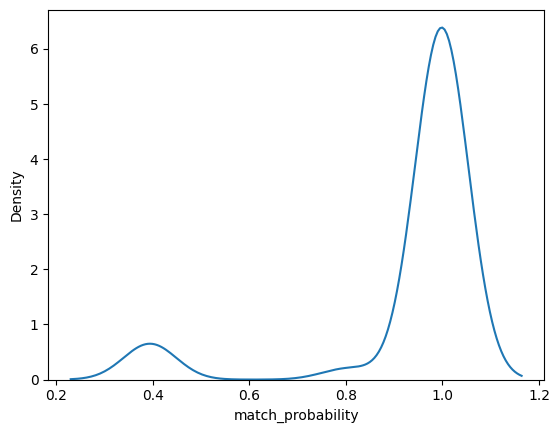

In [69]:
# Density plot to show distribution of match probabilities
sns.kdeplot(data_subset['match_probability'])

Within data_subset, a majority of our probabilities are at a higher scale - meaning that our EM model is confident in a lot of these candidates being matches. 

<Axes: xlabel='match_probability', ylabel='Density'>

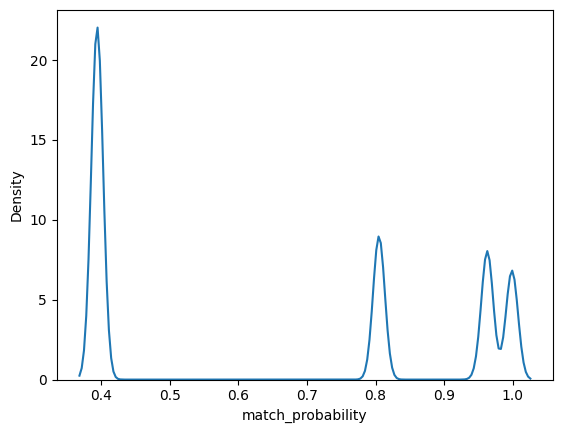

In [70]:
sns.kdeplot(preds['match_probability'])

On the other hand, in looking at the distribution for our match probabilities from `preds`, our model has much less confidence in the probability values, with a majority of values converging around $0.4$. 

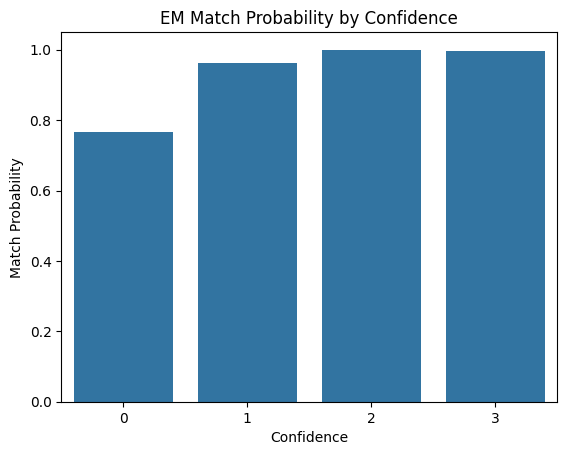

In [ ]:
# Barchart of match probabilities by confidence
agg_confidence = data_subset.groupby('confidence')['match_probability'].mean().reset_index()
sns.barplot(x="confidence", y="match_probability", data=agg_confidence)
plt.xlabel("Confidence")
plt.ylabel("Match Probability")
plt.title("EM Match Probability by Confidence")
plt.show()

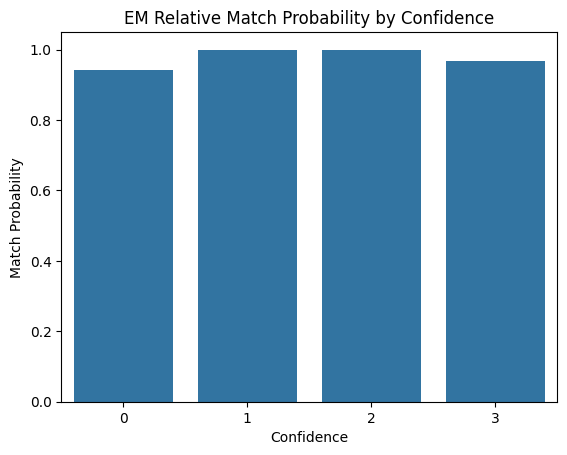

In [ ]:
# Barchart of relative match probabilities by confidence
agg_confidence = data_subset.dropna().groupby('confidence')['relatives_match_probability'].mean().reset_index()
sns.barplot(x="confidence", y="relatives_match_probability", data=agg_confidence)
plt.xlabel("Confidence")
plt.ylabel("Match Probability")
plt.title("EM Relative Match Probability by Confidence")
plt.show()

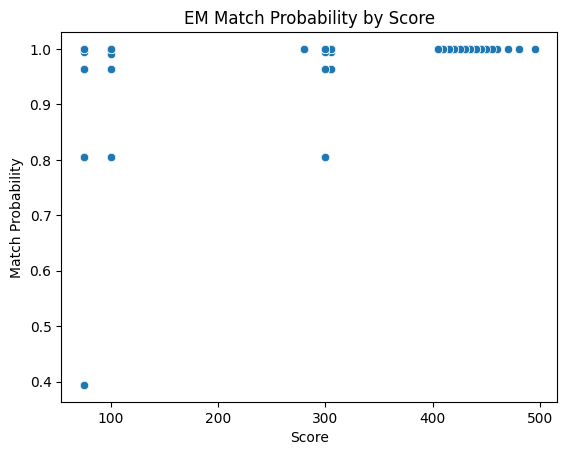

In [41]:
# Scatterplot of score/match_probability 
sns.scatterplot(x="score", y="match_probability", data=data_subset)
plt.xlabel("Score")
plt.ylabel("Match Probability")
plt.title("EM Match Probability by Score")
plt.show()

#### Investigate the contents of ground truth

In [44]:
# Look at the summary stats for score/confidence
ground_truth[['score', 'confidence']].describe()

,score,confidence
count,353.000000,353.000000
mean,247.776204,1.929178
std,120.857252,1.349694
min,75.000000,0.000000
25%,100.000000,0.000000
50%,300.000000,3.000000
75%,305.000000,3.000000
max,495.000000,3.000000


In [46]:
ground_truth['score'].nunique(), ground_truth['confidence'].nunique()


(20, 4)

In [47]:
ground_truth['score'].value_counts().head(20)


score
300    100
75      67
280     47
100     46
305     41
410     11
415      7
440      6
405      6
430      5
420      5
445      3
435      2
495      1
480      1
470      1
460      1
455      1
450      1
425      1
Name: count, dtype: int64

In [48]:
ground_truth['confidence'].value_counts()

confidence
3    206
0    103
1     25
2     19
Name: count, dtype: int64

In [50]:
pd.crosstab(ground_truth['confidence'], ground_truth['score'])

score,75,100,280,300,305,405,410,415,420,425,430,435,440,445,450,455,460,470,480,495
confidence,,,,,,,,,,,,,,,,,,,,
0,61,33,4,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,4,9,3,6,2,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,0,4,6,5,2,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,2,0,34,87,34,5,11,7,3,1,5,2,6,3,1,1,1,1,1,1


1. Treat `confidence=3` as a "perfect" match (essentially `match=1`), and measure auc, log loss, brier score, accuracy, and calibration

In [72]:
binary_eval = data_subset.loc[
# Treat confidence as binary label for 0/3 being 3 = 1
    data_subset['confidence'].isin([0, 3]),
    ['confidence', 'match_probability']
].dropna(subset=['match_probability'])
y_true = (binary_eval['confidence'] == 3).astype(int)
y_prob = binary_eval['match_probability']

In [77]:
# Get AUC
auc = roc_auc_score(y_true, y_prob)
# Get Brier score
brier = brier_score_loss(y_true, y_prob)
# Get log loss
log_loss = -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))
# Get overall "accuracy" (if predicted match >= 0.5, it's a match)
accuracy = (y_true == (y_prob >= 0.5)).mean()
print(f"AUC: {auc:.4f}")
print(f"Brier: {brier:.4f}")
print(f"Log loss: {log_loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"n = {len(binary_eval)} (dropped {len(data_subset) - len(binary_eval)} unmatched rows, unmatched being when confidence != 0 or 3)")

AUC: 0.9373
Brier: 0.1823
Log loss: 1.2630
Accuracy: 0.8198
n = 283 (dropped 70 unmatched rows, unmatched being when confidence != 0 or 3)


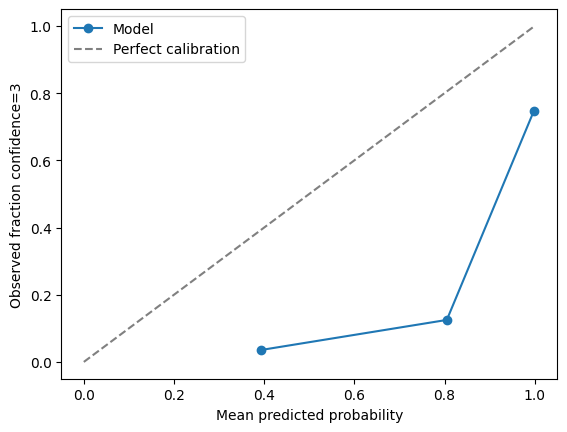

In [54]:
# Calibration plot
def calibration_data(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)
    df_cal = pd.DataFrame({'bin': bin_ids, 'y_true': y_true, 'y_prob': y_prob})
    grouped = df_cal.groupby('bin').agg(
        mean_pred=('y_prob', 'mean'),
        mean_true=('y_true', 'mean'),
        n=('y_true', 'count')
    ).reset_index()
    return grouped

cal = calibration_data(y_true.values, y_prob.values)
plt.plot(cal['mean_pred'], cal['mean_true'], marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed fraction confidence=3')
plt.legend()
plt.show()

Our model's `AUC = 0.937` indicates that our model is effective in discriminating "true" matches ahead of non-matches. Further, an overall `"accuracy" = $.8198$` is solid, meaning our model is over $80\%$ effective in determining a true match, however, we know the distribution of confidence values are right-skew, so with any lenient model, it's only a slight improvement over a dataset with a majority of the observations being a match. A brier score of $0.1823$ is solid, and aligns similarly to the AUC's performance, however, where the brier score stands out is that it indicates our model isn't well-calibrated as it's not as low as the AUC might've suggested. Lastly, and most notably, the logloss ($1.2630$) is very poor, and highlights that oftentimes many of our model predictions are overconfident. For example, with instances like Dabney Johnson, because the name is common, our model treats that as a "match" and is unable to discern which Dabney Johnson is which at the same time, and our EM probabilities are **considerably** high for a true non-match. While "boosting" provides better insight into which exact match belongs to each candidate pair, it can't penalize poor relative probabilities. The calibration confirms this, as our highly confident predictions (around $1$ for a prpobability) only correspond to a true match rate at around $75\%$, and our less confident predictions ($\approx 0.4$) correspond to a true match rate of around $0\%$ with the ground truth data provided.